In [12]:

import warnings
warnings.filterwarnings("ignore")

import gc
import joblib
from datetime import date, datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna

# Sklearn — model selection
from sklearn.model_selection import train_test_split, StratifiedKFold

# Sklearn — pipeline e preprocessamento
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import VarianceThreshold

# Sklearn — métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)

# Sklearn — modelos
from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble      import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection    import permutation_importance

# Modelos externos
import lightgbm as lgb
from lightgbm  import LGBMClassifier
from xgboost   import XGBClassifier
from catboost  import CatBoostClassifier

# Encoders
from category_encoders import TargetEncoder
import json
#import shap

pd.set_option('display.float_format', '{:.4f}'.format)

hoje = date.today()

In [26]:
#Base de treino:
#C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Intermediarios\01train_bureau.parquet
#C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Intermediarios\02train_installments.parquet
#C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Intermediarios\03tain_creditcard.parquet
#C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Intermediarios\04train_poscash.parquet
#C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Intermediarios\05train_previous.parquet


#Base de teste:
#C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Intermediarios\01test_bureau.parquet
#C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Intermediarios\02test_installments.parquet
#C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Intermediarios\03test_creditcard.parquet
#C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Intermediarios\04test_poscash.parquet
#C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Intermediarios\05test_previous.parquet

#### Running de inicialização

In [13]:
RUNNING_IMPORTANCE = False
RUNNING_TUNNING = True

### Importando Book -> Tirando Mau na Origem e Target missing

In [14]:
df_treino = pd.read_parquet(r'C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Intermediarios\03train_creditcard.parquet')
df_treino = df_treino[~df_treino['TARGET'].isna()]

df_teste = pd.read_parquet(r'C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Intermediarios\03test_creditcard.parquet')

In [15]:
print("Shape de df_treino:", df_treino.shape)
print("Total de colunas:", len(df_treino.columns))

#Cols duplicadas
colunas = df_treino.columns.tolist()
duplicadas = [c for c in set(colunas) if colunas.count(c) > 1]
print("Colunas com nome duplicado:", len(duplicadas))
print(duplicadas[:20])

Shape de df_treino: (307511, 3514)
Total de colunas: 3514
Colunas com nome duplicado: 0
[]


Importância de Variáveis

In [16]:
X = df_treino.drop(columns=['SK_ID_CURR','TARGET'])
y = df_treino['TARGET']

In [ ]:
# 1- Remover variáveis com baixa variância
def remove_low_variance(X, threshold=0.99):
    X_num = X.select_dtypes(exclude='object')
    cols_remover = []
    for col in X_num.columns:
        freq_moda = X_num[col].value_counts(normalize=True, dropna=False).iloc[0]
        if freq_moda >= threshold:
            cols_remover.append(col)
    return [c for c in X_num.columns if c not in cols_remover]


# 2- IV e KS univariados

def calcular_iv_ks(X, y, coluna, n_bins=10, min_amostra=500):
    
    dados = pd.DataFrame({'var': X[coluna], 'target': y}).dropna()
    pct_missing = round(X[coluna].isnull().mean() * 100, 2)

    if len(dados) < min_amostra or dados['target'].nunique() < 2:
        return {'variavel': coluna, 'iv': np.nan, 'ks': np.nan, 'pct_missing': pct_missing}

    try:
        dados['bin'] = pd.qcut(dados['var'], q=n_bins, duplicates='drop')
    except ValueError:
        return {'variavel': coluna, 'iv': np.nan, 'ks': np.nan, 'pct_missing': pct_missing}

    grp = dados.groupby('bin', observed=True)['target'].agg(['count', 'sum'])
    grp['bom'] = grp['count'] - grp['sum']
    grp['mau'] = grp['sum']
    total_bom = grp['bom'].sum()
    total_mau = grp['mau'].sum()

    grp['pct_bom'] = grp['bom'] / total_bom
    grp['pct_mau'] = grp['mau'] / total_mau
    grp['woe'] = np.log((grp['pct_bom'].replace(0, 1e-6)) / (grp['pct_mau'].replace(0, 1e-6)))
    grp['iv_bin'] = (grp['pct_bom'] - grp['pct_mau']) * grp['woe']
    iv = grp['iv_bin'].sum()

    grp_sorted = grp.sort_index()
    ks = (grp_sorted['pct_bom'].cumsum() - grp_sorted['pct_mau'].cumsum()).abs().max()

    return {
        'variavel': coluna,
        'iv': round(iv, 4),
        'ks': round(ks, 4),
        'pct_missing': pct_missing
    }


def iv_ks_filter(X, y, cols, iv_min=0.02, n_bins=10, min_amostra=500):
    '''Roda IV/KS para uma lista de colunas numéricas e filtra pelo IV mínimo.'''
    resultados = [calcular_iv_ks(X, y, c, n_bins=n_bins, min_amostra=min_amostra) for c in cols]
    df_iv = pd.DataFrame(resultados).sort_values('iv', ascending=False).reset_index(drop=True)
    cols_aprovadas = df_iv.loc[df_iv['iv'] >= iv_min, 'variavel'].tolist()
    return df_iv, cols_aprovadas


# 3- Correlação entre variáveis numéricas

def correlation_filter(X, threshold=0.50):

    X_num       = X.select_dtypes(include=np.number)
    corr_matrix = X_num.corr().abs()
    upper       = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    remove      = [column for column in upper.columns if any(upper[column] > threshold)]
    return remove


# 4- Feature importance LightGBM

def lgbm_feature_importance(X_train, y_train, cat_cols=None):
    X_fit = X_train.copy()
    if cat_cols:
        for c in cat_cols:
            X_fit[c] = X_fit[c].astype('category')

    model = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05
    )
    model.fit(X_fit, y_train, categorical_feature=cat_cols if cat_cols else 'auto')
    importance = pd.DataFrame({
        "variavel"  : X_fit.columns,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False).reset_index(drop=True)
    return importance


# 5- Rodar seleção
#e o split é só um holdout estratificado simples

X_sel = X
y_sel = y

# Split ANTES da seleção — importância calculada só no treino
X_sel_train, X_sel_test, y_sel_train, _ = train_test_split(
    X_sel, y_sel, test_size=0.30, stratify=y_sel, random_state=0
)

print("Shape inicial:", X_sel_train.shape)

cat_cols_sel = X_sel_train.select_dtypes(include='object').columns.tolist()
print("Colunas categóricas identificadas:", len(cat_cols_sel))

# Baixa variância fit no treino
cols_lowvar = remove_low_variance(X_sel_train, threshold=0.99)
print("\nApós baixa variância:", len(cols_lowvar))

# IV/KS fit no treino
df_iv, cols_iv_aprovadas = iv_ks_filter(X_sel_train, y_sel_train, cols_lowvar, iv_min=0.02)
print("Após filtro de IV (>= 0.02):", len(cols_iv_aprovadas))
print(df_iv.head(15))

# Correlação fit no treino — só entre as já aprovadas por IV
cols_iv_ordenadas = df_iv[df_iv['variavel'].isin(cols_iv_aprovadas)].sort_values('iv', ascending=False)['variavel'].tolist()
corr_remove = correlation_filter(X_sel_train[cols_iv_ordenadas], threshold=0.90)
print("\nVariáveis removidas por correlação:", len(corr_remove))

cols_finais_num = [c for c in cols_iv_aprovadas if c not in corr_remove]
cols_finais = cols_finais_num + cat_cols_sel

X_final_train = X_sel_train[cols_finais]
print("Shape final após filtros:", X_final_train.shape)

# Importância LightGBM - (astype category + categorical_feature)
importance = lgbm_feature_importance(X_final_train, y_sel_train, cat_cols=cat_cols_sel)
importance

Salvando Lista das Top Variáveis

In [25]:
if RUNNING_IMPORTANCE:
    file_path_vars = r'C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Modelo\Variaveis\vars_selecionadas-03-CreditCard.json'

    importance = importance[importance['importance'] > 0]
    vars = importance['variavel'].to_list()
    vars = vars[:50]

    with open(file_path_vars, 'w', encoding='utf-8') as f:
            json.dump(vars, f, ensure_ascii=False, indent=2)
    
    print(f"{len(vars)} variáveis salvas em: {file_path_vars}")

else:
    file_path_vars = r'C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Modelo\Variaveis\vars_selecionadas-03-CreditCard.json'

    with open(file_path_vars, 'r', encoding='utf-8') as f:
        vars = json.load(f)

    vars = vars[:50]
    print(f"{len(vars)} variáveis carregadas.")
    print(vars[:5])

50 variáveis carregadas.
['ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AMT_GOODS_PRICE']


## Parte 1 — Preparando os dados (sem treinar ainda)

In [26]:
# ATENÇÃO: aqui só preparamos os dados (split + imputação + encoding).

COLS_TIRAR_TREINO = ['SK_ID_CURR', 'TARGET']
cols_remover_treino = [c for c in COLS_TIRAR_TREINO if c in df_treino.columns]

X = df_treino.drop(columns=cols_remover_treino)
y = df_treino['TARGET']

X = X[vars]

# Base oficial de teste da Home Credit — guarda o SK_ID_CURR à parte,
# ele não entra no modelo mas é obrigatório na submissão final.
ids_teste = df_teste['SK_ID_CURR'].copy()
X_teste = df_teste[vars].copy()  # mesmas colunas selecionadas

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=0
)

# Guarda os SK_ID_CURR do holdout e do treino, alinhados por índice — vai
ids_train = df_treino.loc[X_train.index, 'SK_ID_CURR'].values
ids_test  = df_treino.loc[X_test.index,  'SK_ID_CURR'].values

# ======================================================
# Identificação das colunas
# ======================================================

cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]

# ======================================================
# Missing numéricos
# NÃO imputamos os numéricos para os modelos de árvore que tratam NaN
# ======================================================

medians = X_train[num_cols].median()

X_train_imp = X_train.copy()
X_test_imp  = X_test.copy()
X_teste_imp = X_teste.copy()

X_train_imp[num_cols] = X_train_imp[num_cols].fillna(medians)
X_test_imp[num_cols]  = X_test_imp[num_cols].fillna(medians)
X_teste_imp[num_cols] = X_teste_imp[num_cols].fillna(medians)

# ======================================================
# Missing categóricos — preenchidos com a moda em todas as versões
# ======================================================

mode = X_train[cat_cols].mode().iloc[0]

for _df in (X_train, X_test, X_teste, X_train_imp, X_test_imp, X_teste_imp):
    _df[cat_cols] = _df[cat_cols].fillna(mode)

def target_encode_oof(X_train, y_train, X_test, X_teste, cat_cols, n_splits=5, random_state=0, **encoder_kwargs):
    X_train_enc = X_train.copy()
    oof_cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    oof_values = pd.DataFrame(index=X_train.index, columns=cat_cols, dtype=float)

    for tr_idx, val_idx in oof_cv.split(X_train, y_train):
        fold_encoder = TargetEncoder(cols=cat_cols, **encoder_kwargs)
        fold_encoder.fit(X_train.iloc[tr_idx][cat_cols], y_train.iloc[tr_idx])
        transformado = fold_encoder.transform(X_train.iloc[val_idx][cat_cols])
        oof_values.iloc[val_idx] = transformado.values

    X_train_enc[cat_cols] = oof_values

    encoder_final = TargetEncoder(cols=cat_cols, **encoder_kwargs)
    encoder_final.fit(X_train[cat_cols], y_train)

    X_test_enc  = X_test.copy()
    X_teste_enc = X_teste.copy()
    X_test_enc[cat_cols]  = encoder_final.transform(X_test[cat_cols])
    X_teste_enc[cat_cols] = encoder_final.transform(X_teste[cat_cols])

    return X_train_enc, X_test_enc, X_teste_enc, encoder_final


X_train, X_test, X_teste, encoder = target_encode_oof(
    X_train, y_train, X_test, X_teste, cat_cols
)
X_train_imp, X_test_imp, X_teste_imp, encoder_imp = target_encode_oof(
    X_train_imp, y_train, X_test_imp, X_teste_imp, cat_cols
)

print("X_train:", X_train.shape, "| X_test:", X_test.shape, "| X_teste (Kaggle):", X_teste.shape)
print("Missing em X_train (modelos de árvore):", X_train.isna().sum().sum(), "células")

# ======================================================
# Padronização — só usada pela LogisticRegression
# ======================================================

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=X_train_imp.columns, index=X_train_imp.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test_imp),  columns=X_test_imp.columns,  index=X_test_imp.index)
X_teste_scaled = pd.DataFrame(scaler.transform(X_teste_imp), columns=X_teste_imp.columns, index=X_teste_imp.index)

X_train: (215257, 50) | X_test: (92254, 50) | X_teste (Kaggle): (48744, 50)
Missing em X_train (modelos de árvore): 2148956 células


## Comparação de modelos

In [27]:
# ======================================================
# Função KS
# ======================================================

def ks_score(y_true, prob):
    fpr, tpr, _ = roc_curve(y_true, prob)
    return np.max(tpr - fpr)

# ======================================================
# Modelos
# (idêntico ao behavioral — a comparação de algoritmos não muda entre
# application e behavior, o que muda é a leitura das métricas)
# ======================================================

models = {

    "Random Forest": RandomForestClassifier(
        #n_estimators=300,
        #max_depth=5,
        random_state=0
        #n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        #n_estimators=300,
        #learning_rate=0.05,
        #max_depth=5,
        random_state=0
        #verbose=-1
    ),

    "CatBoost": CatBoostClassifier(
        #iterations=300,
        #learning_rate=0.05,
        #depth=5,
        random_state=0
        #verbose=False
    ),

    "GradientBoosting": GradientBoostingClassifier(
        #n_estimators=300,
        #learning_rate=0.05,
        #max_depth=5,
        random_state=0
    ),

    "LogisticRegression": LogisticRegression(
        max_iter=2000,
        random_state=0,
        n_jobs=-1
    )
}

# ======================================================
# Avaliação
# NOTA: dataset desbalanceado (~8% TARGET=1). Accuracy/Precision/Recall
# usam threshold padrão de 0.5 do predict(), que nesse cenário tende a
# prever quase tudo como classe 0 (accuracy alta e enganosa, recall baixo).
# O critério de decisão real é ROC AUC / KS / Gini, como no behavioral.
#
# Cada modelo usa a versão dos dados compatível com seu suporte a NaN:
# - LightGBM / CatBoost: NaN nativo -> X_train / X_test (sem imputação,
#   preserva o sinal de "ausência" nas variáveis CC_* de alto missing).
# - RandomForest / GradientBoosting (sklearn): não aceitam NaN -> versão
#   imputada X_train_imp / X_test_imp.
# - LogisticRegression: sensível a escala e não aceita NaN -> versão
#   imputada e padronizada X_train_scaled / X_test_scaled.
# ======================================================

MODELOS_NAN_NATIVO = {"LightGBM", "CatBoost"}

resultados = []

for nome, modelo in models.items():

    if nome == "LogisticRegression":
        X_tr, X_te = X_train_scaled, X_test_scaled
    elif nome in MODELOS_NAN_NATIVO:
        X_tr, X_te = X_train, X_test
    else:
        X_tr, X_te = X_train_imp, X_test_imp

    modelo.fit(X_tr, y_train)

    pred_train = modelo.predict(X_tr)
    prob_train = modelo.predict_proba(X_tr)[:, 1]

    auc_train  = roc_auc_score(y_train, prob_train)
    gini_train = 2 * auc_train - 1
    ks_train   = ks_score(y_train, prob_train)

    pred_test = modelo.predict(X_te)
    prob_test = modelo.predict_proba(X_te)[:, 1]

    auc_test  = roc_auc_score(y_test, prob_test)
    gini_test = 2 * auc_test - 1
    ks_test   = ks_score(y_test, prob_test)

    resultados.append({
        "Modelo": nome,
        "Accuracy Train": accuracy_score(y_train, pred_train),
        "Accuracy Test": accuracy_score(y_test, pred_test),
        "Precision Train": precision_score(y_train, pred_train, zero_division=0),
        "Precision Test": precision_score(y_test, pred_test, zero_division=0),
        "Recall Train": recall_score(y_train, pred_train, zero_division=0),
        "Recall Test": recall_score(y_test, pred_test, zero_division=0),
        "ROC AUC Train": auc_train,
        "ROC AUC Test": auc_test,
        "Gini Train": gini_train,
        "Gini Test": gini_test,
        "KS Train": ks_train,
        "KS Test": ks_test,
        "Gap AUC": auc_train - auc_test,
        "Gap KS": ks_train - ks_test,
        "Gap Accuracy": accuracy_score(y_train, pred_train) - accuracy_score(y_test, pred_test)
    })


resultado_modelos = (
    pd.DataFrame(resultados)
      .sort_values("ROC AUC Test", ascending=False)
      .round(4)
      .reset_index(drop=True)
)

resultado_modelos

Learning rate set to 0.102119
0:	learn: 0.5889148	total: 81.3ms	remaining: 1m 21s
1:	learn: 0.5110819	total: 140ms	remaining: 1m 9s
2:	learn: 0.4521089	total: 185ms	remaining: 1m 1s
3:	learn: 0.4089007	total: 239ms	remaining: 59.5s
4:	learn: 0.3751391	total: 295ms	remaining: 58.8s
5:	learn: 0.3505959	total: 329ms	remaining: 54.6s
6:	learn: 0.3297334	total: 362ms	remaining: 51.3s
7:	learn: 0.3135995	total: 399ms	remaining: 49.5s
8:	learn: 0.3008625	total: 478ms	remaining: 52.6s
9:	learn: 0.2919738	total: 541ms	remaining: 53.6s
10:	learn: 0.2839009	total: 581ms	remaining: 52.2s
11:	learn: 0.2780785	total: 618ms	remaining: 50.9s
12:	learn: 0.2734767	total: 655ms	remaining: 49.7s
13:	learn: 0.2693943	total: 688ms	remaining: 48.5s
14:	learn: 0.2661498	total: 722ms	remaining: 47.4s
15:	learn: 0.2631310	total: 759ms	remaining: 46.7s
16:	learn: 0.2610005	total: 795ms	remaining: 46s
17:	learn: 0.2592470	total: 831ms	remaining: 45.4s
18:	learn: 0.2577497	total: 866ms	remaining: 44.7s
19:	learn: 

,Modelo,Accuracy Train,Accuracy Test,Precision Train,Precision Test,Recall Train,Recall Test,ROC AUC Train,ROC AUC Test,Gini Train,Gini Test,KS Train,KS Test,Gap AUC,Gap KS,Gap Accuracy
0,CatBoost,0.9292,0.9193,0.9356,0.5007,0.1320,0.0473,0.8538,0.7737,0.7075,0.5475,0.5393,0.4121,0.0800,0.1272,0.0099
1,LightGBM,0.9216,0.9194,0.7355,0.5097,0.0445,0.0318,0.8222,0.7716,0.6444,0.5432,0.4878,0.4055,0.0506,0.0822,0.0022
2,GradientBoosting,0.9200,0.9195,0.6181,0.5272,0.0251,0.0247,0.7758,0.7648,0.5515,0.5296,0.4117,0.3976,0.0110,0.0141,0.0006
3,LogisticRegression,0.9191,0.9191,0.4657,0.4598,0.0144,0.0138,0.7463,0.7463,0.4925,0.4925,0.3704,0.3671,-0.0000,0.0033,0.0000
4,Random Forest,1.0000,0.9196,1.0000,0.6709,0.9995,0.0071,1.0000,0.7303,1.0000,0.4606,1.0000,0.3456,0.2697,0.6544,0.0804


In [28]:
# ======================================================
# Função KS
# ======================================================

def ks_score(y_true, prob):
    fpr, tpr, _ = roc_curve(y_true, prob)
    return np.max(tpr - fpr)

# ======================================================
# Modelos — parâmetros ajustados para maximizar AUC/discriminação
# Principal mudança: todos agora tratam o desbalanceamento de classe
# (~8% positivo), que a configuração anterior ignorava por completo.
# ======================================================

models = {

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        max_depth=10,              # sem limite tende a decorar; 10 dá capacidade real sem exagero
        min_samples_leaf=50,       # evita folhas com poucos exemplos (ruído)
        class_weight="balanced",   # NOVO — compensa o desbalanceamento
        random_state=0,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,               # sem limite explícito, num_leaves já controla
        min_child_samples=100,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=11.5,      # NOVO — ~92/8, compensa desbalanceamento
        random_state=0,
        verbose=-1
    ),

    "CatBoost": CatBoostClassifier(
        iterations=1000,
        learning_rate=0.03,
        depth=6,
        l2_leaf_reg=3.0,
        auto_class_weights="Balanced",  # NOVO — equivalente ao scale_pos_weight
        random_state=0,
        verbose=False
    ),

    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,               # amostragem estocástica — melhora generalização
        min_samples_leaf=50,
        random_state=0
        # GradientBoostingClassifier não suporta class_weight nativamente;
        # se quiser compensar desbalanceamento, seria via sample_weight manual
    ),

    "LogisticRegression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",   # NOVO — compensa o desbalanceamento
        C=0.5,                      # regularização um pouco mais forte que o padrão (C=1.0)
        random_state=0,
        n_jobs=-1
    )
}

# ======================================================
# Avaliação
# NOTA: dataset desbalanceado (~8% TARGET=1). Accuracy/Precision/Recall
# usam threshold padrão de 0.5 do predict(), que nesse cenário tende a
# prever quase tudo como classe 0 (accuracy alta e enganosa, recall baixo).
# O critério de decisão real é ROC AUC / KS / Gini, como no behavioral.
#
# Cada modelo usa a versão dos dados compatível com seu suporte a NaN:
# - LightGBM / CatBoost: NaN nativo -> X_train / X_test (sem imputação,
#   preserva o sinal de "ausência" nas variáveis CC_* de alto missing).
# - RandomForest / GradientBoosting (sklearn): não aceitam NaN -> versão
#   imputada X_train_imp / X_test_imp.
# - LogisticRegression: sensível a escala e não aceita NaN -> versão
#   imputada e padronizada X_train_scaled / X_test_scaled.
# ======================================================

MODELOS_NAN_NATIVO = {"LightGBM", "CatBoost"}

resultados = []

for nome, modelo in models.items():

    if nome == "LogisticRegression":
        X_tr, X_te = X_train_scaled, X_test_scaled
    elif nome in MODELOS_NAN_NATIVO:
        X_tr, X_te = X_train, X_test
    else:
        X_tr, X_te = X_train_imp, X_test_imp

    modelo.fit(X_tr, y_train)

    pred_train = modelo.predict(X_tr)
    prob_train = modelo.predict_proba(X_tr)[:, 1]

    auc_train  = roc_auc_score(y_train, prob_train)
    gini_train = 2 * auc_train - 1
    ks_train   = ks_score(y_train, prob_train)

    pred_test = modelo.predict(X_te)
    prob_test = modelo.predict_proba(X_te)[:, 1]

    auc_test  = roc_auc_score(y_test, prob_test)
    gini_test = 2 * auc_test - 1
    ks_test   = ks_score(y_test, prob_test)

    resultados.append({
        "Modelo": nome,
        "Accuracy Train": accuracy_score(y_train, pred_train),
        "Accuracy Test": accuracy_score(y_test, pred_test),
        "Precision Train": precision_score(y_train, pred_train, zero_division=0),
        "Precision Test": precision_score(y_test, pred_test, zero_division=0),
        "Recall Train": recall_score(y_train, pred_train, zero_division=0),
        "Recall Test": recall_score(y_test, pred_test, zero_division=0),
        "ROC AUC Train": auc_train,
        "ROC AUC Test": auc_test,
        "Gini Train": gini_train,
        "Gini Test": gini_test,
        "KS Train": ks_train,
        "KS Test": ks_test,
        "Gap AUC": auc_train - auc_test,
        "Gap KS": ks_train - ks_test,
        "Gap Accuracy": accuracy_score(y_train, pred_train) - accuracy_score(y_test, pred_test)
    })


resultado_modelos = (
    pd.DataFrame(resultados)
      .sort_values("ROC AUC Test", ascending=False)
      .round(4)
      .reset_index(drop=True)
)

resultado_modelos

,Modelo,Accuracy Train,Accuracy Test,Precision Train,Precision Test,Recall Train,Recall Test,ROC AUC Train,ROC AUC Test,Gini Train,Gini Test,KS Train,KS Test,Gap AUC,Gap KS,Gap Accuracy
0,CatBoost,0.7391,0.7307,0.1998,0.1834,0.7426,0.6764,0.8208,0.7760,0.6416,0.5521,0.4836,0.4136,0.0448,0.0700,0.0084
1,LightGBM,0.7757,0.7501,0.2407,0.1912,0.8250,0.6488,0.8810,0.7747,0.7620,0.5494,0.5989,0.4124,0.1063,0.1865,0.0256
2,GradientBoosting,0.9214,0.9197,0.6938,0.5347,0.0467,0.0393,0.7920,0.7706,0.5840,0.5413,0.4377,0.4056,0.0214,0.0322,0.0017
3,Random Forest,0.7292,0.7167,0.1926,0.1721,0.7374,0.6586,0.8106,0.7569,0.6212,0.5139,0.4672,0.3834,0.0536,0.0839,0.0125
4,LogisticRegression,0.6927,0.6948,0.1622,0.1628,0.6739,0.6711,0.7467,0.7466,0.4934,0.4932,0.3725,0.3690,0.0001,0.0035,-0.0020


### Optuna - LGBM

In [111]:
OPTUNA_EARLY_STOPING = 20  #padrão: 25

class EarlyStoppingExceeded(optuna.exceptions.OptunaError):
    early_stop = OPTUNA_EARLY_STOPING
    early_stop_count = 0
    best_score = None

def early_stopping_opt(study, trial):
    if EarlyStoppingExceeded.best_score is None:
        EarlyStoppingExceeded.best_score = study.best_value

    if study.best_value > EarlyStoppingExceeded.best_score:
        EarlyStoppingExceeded.best_score = study.best_value
        EarlyStoppingExceeded.early_stop_count = 0
    else:
        if EarlyStoppingExceeded.early_stop_count > EarlyStoppingExceeded.early_stop:
            EarlyStoppingExceeded.early_stop_count = 0
            EarlyStoppingExceeded.best_score = None
            raise EarlyStoppingExceeded()
        else:
            EarlyStoppingExceeded.early_stop_count += 1
    return


cv = StratifiedKFold(5, shuffle=True, random_state=42)

# Penaliza o objetivo pelo gap treino-validação, não só pela AUC pura.

GAP_PENALTY = 0.05 #padrão 0.5

def obj(trial):

    model = lgb.LGBMClassifier(
        objective         = "binary",
        verbosity         = -1,
        random_state      = 42,
        n_estimators      = 3000,
        boosting_type     = "gbdt",
        learning_rate     = trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        max_depth         = trial.suggest_int("max_depth", 3, 12),
        reg_alpha         = trial.suggest_float("lambda_l1", 1e-8, 20.0, log=True),
        reg_lambda        = trial.suggest_float("lambda_l2", 1e-8, 20.0, log=True),
        num_leaves        = trial.suggest_int("num_leaves", 2, 256),
        colsample_bytree  = trial.suggest_float("feature_fraction", 0.05, 1.0),
        subsample         = trial.suggest_float("bagging_fraction", 0.05, 1.0),
        subsample_freq    = trial.suggest_int("bagging_freq", 1, 10),
        min_child_samples = trial.suggest_int("min_child_samples", 5, 100),
        min_child_weight  = trial.suggest_float("min_child_weight", 1e-3, 10.0, log=True),
        is_unbalance      = trial.suggest_categorical("is_unbalance", [True, False]),
    )

    s_auc = []
    s_gap = []
    iteracoes = []

    for tr, va in cv.split(X_train, y_train):
        model.fit(
            X_train.iloc[tr], y_train.iloc[tr],
            eval_set=[(X_train.iloc[va], y_train.iloc[va])],
            eval_metric='auc',
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
        )
        p_va = model.predict_proba(X_train.iloc[va])[:, 1]
        p_tr = model.predict_proba(X_train.iloc[tr])[:, 1]

        auc_va = roc_auc_score(y_train.iloc[va].values, p_va)
        auc_tr = roc_auc_score(y_train.iloc[tr].values, p_tr)

        s_auc.append(auc_va)
        s_gap.append(auc_tr - auc_va)
        iteracoes.append(model.best_iteration_)

    AUC = np.mean(s_auc)
    GAP = np.mean(s_gap)
    SCORE = AUC - GAP_PENALTY * GAP

    trial.set_user_attr("mean_best_iteration", int(np.mean(iteracoes)))
    trial.set_user_attr("mean_auc", float(AUC))
    trial.set_user_attr("mean_gap", float(GAP))

    print(f'auc = {AUC:.4f} | gap = {GAP:.4f} | score = {SCORE:.4f}')

    return SCORE


# Exec Tunagem
if RUNNING_TUNNING:
    study = optuna.create_study(direction="maximize")

    try:
        study.optimize(obj, n_trials=100, callbacks=[early_stopping_opt])
    except EarlyStoppingExceeded:
        print(f'EarlyStopping do Optuna acionado: sem melhora em {OPTUNA_EARLY_STOPING} trials seguidos.')

    print("Número de trials realizados:", len(study.trials))

    best_params = study.best_params
    melhor_score = study.best_value
    melhor_auc = study.best_trial.user_attrs["mean_auc"]
    n_estimators_final = study.best_trial.user_attrs["mean_best_iteration"]
    melhor_gap = study.best_trial.user_attrs["mean_gap"]

    print(f"\nMelhores parâmetros: {best_params}")
    print(f"Melhor AUC (CV): {melhor_auc:.4f}")
    print(f"Gap (CV) do melhor trial: {melhor_gap:.4f}")
    print(f"Score (AUC - {GAP_PENALTY}*gap): {melhor_score:.4f}")
    print(f"Nº de árvores (média do CV): {n_estimators_final}")

else:
    best_params = {
        'learning_rate': 0.05, 'max_depth': 8,
        'lambda_l1': 0.0, 'lambda_l2': 0.0, 'num_leaves': 31,
        'feature_fraction': 0.8, 'bagging_fraction': 0.8, 'bagging_freq': 1,
        'min_child_samples': 20, 'min_child_weight': 1e-3, 'is_unbalance': False
    }
    n_estimators_final = 979  # ajuste para o valor real dessa rodada

    print("Melhores parâmetros:", best_params)

[I 2026-09-06 01:59:12,958] A new study created in memory with name: no-name-f2dce0cb-5ccb-4cc8-900f-5d7f334753c0
[I 2026-09-06 02:00:15,557] Trial 0 finished with value: 0.7714668443979906 and parameters: {'learning_rate': 0.03664183566570395, 'max_depth': 9, 'lambda_l1': 0.00059995788688435, 'lambda_l2': 3.859466658890839e-05, 'num_leaves': 26, 'feature_fraction': 0.4530551006582446, 'bagging_fraction': 0.9124337619869879, 'bagging_freq': 3, 'min_child_samples': 37, 'min_child_weight': 2.5217301721725818, 'is_unbalance': False}. Best is trial 0 with value: 0.7714668443979906.


auc = 0.7746 | gap = 0.0625 | score = 0.7715


[I 2026-09-06 02:01:05,304] Trial 1 finished with value: 0.7642281570627456 and parameters: {'learning_rate': 0.04675133696224421, 'max_depth': 10, 'lambda_l1': 0.029901855708795146, 'lambda_l2': 0.0912060232654174, 'num_leaves': 58, 'feature_fraction': 0.16189176898271304, 'bagging_fraction': 0.41211085511686857, 'bagging_freq': 10, 'min_child_samples': 76, 'min_child_weight': 1.5117511476277812, 'is_unbalance': False}. Best is trial 0 with value: 0.7714668443979906.


auc = 0.7686 | gap = 0.0869 | score = 0.7642


[I 2026-09-06 02:01:18,531] Trial 2 finished with value: 0.7221713620435949 and parameters: {'learning_rate': 0.026805753840346266, 'max_depth': 6, 'lambda_l1': 0.4826697252400259, 'lambda_l2': 0.0028645419489828562, 'num_leaves': 169, 'feature_fraction': 0.9246164194456816, 'bagging_fraction': 0.8033278577827238, 'bagging_freq': 1, 'min_child_samples': 80, 'min_child_weight': 0.05138741406350489, 'is_unbalance': True}. Best is trial 0 with value: 0.7714668443979906.


...

auc = 0.7726 | gap = 0.1660 | score = 0.7643


[I 2026-09-06 02:42:37,409] Trial 28 finished with value: 0.726755037491401 and parameters: {'learning_rate': 0.005067499324371923, 'max_depth': 7, 'lambda_l1': 9.28601118487292e-08, 'lambda_l2': 0.00038220942832094897, 'num_leaves': 79, 'feature_fraction': 0.07838482613940745, 'bagging_fraction': 0.23109990719964127, 'bagging_freq': 6, 'min_child_samples': 9, 'min_child_weight': 0.08941097279454774, 'is_unbalance': False}. Best is trial 7 with value: 0.7740539563108295.


auc = 0.7280 | gap = 0.0246 | score = 0.7268


[I 2026-09-06 02:43:14,053] Trial 29 finished with value: 0.773543050512216 and parameters: {'learning_rate': 0.04673577706042057, 'max_depth': 3, 'lambda_l1': 0.00032294419994784173, 'lambda_l2': 4.94294814457032, 'num_leaves': 12, 'feature_fraction': 0.4206607041225182, 'bagging_fraction': 0.827567147288923, 'bagging_freq': 2, 'min_child_samples': 36, 'min_child_weight': 1.4296579731252494, 'is_unbalance': False}. Best is trial 7 with value: 0.7740539563108295.


auc = 0.7749 | gap = 0.0274 | score = 0.7735
EarlyStopping do Optuna acionado: sem melhora em 20 trials seguidos.
Número de trials realizados: 30

Melhores parâmetros: {'learning_rate': 0.010023663586175487, 'max_depth': 5, 'lambda_l1': 3.5343300514102003e-06, 'lambda_l2': 13.24616657596614, 'num_leaves': 185, 'feature_fraction': 0.36812504246853806, 'bagging_fraction': 0.30522986978794714, 'bagging_freq': 2, 'min_child_samples': 39, 'min_child_weight': 0.3548483799250794, 'is_unbalance': False}
Melhor AUC (CV): 0.7761
Gap (CV) do melhor trial: 0.0415
Score (AUC - 0.05*gap): 0.7741
Nº de árvores (média do CV): 1861


Retreinando o modelo

In [112]:
# Retreina com os melhores parâmetros na base de treino completa,
# usando o número de árvores encontrado no CV (não mais 3000 fixo)
best_lgbm = lgb.LGBMClassifier(
    objective        = "binary",
    verbosity        = -1,
    random_state     = 42,
    n_estimators     = n_estimators_final,
    boosting_type    = "gbdt",
    learning_rate    = best_params["learning_rate"],
    max_depth        = best_params["max_depth"],
    reg_alpha        = best_params["lambda_l1"],
    reg_lambda       = best_params["lambda_l2"],
    num_leaves       = best_params["num_leaves"],
    colsample_bytree = best_params["feature_fraction"],
    subsample        = best_params["bagging_fraction"],
    subsample_freq   = best_params["bagging_freq"],
    min_child_samples= best_params["min_child_samples"],
    min_child_weight = best_params["min_child_weight"],
    is_unbalance     = best_params["is_unbalance"],
)

best_pipe_optuna = Pipeline([("model", best_lgbm)])
best_pipe_optuna.fit(X_train, y_train)

# KS Treino e Teste com o modelo optuna
y_prob_teste_optuna  = best_pipe_optuna.predict_proba(X_test)[:, 1]
y_prob_treino_optuna = best_pipe_optuna.predict_proba(X_train)[:, 1]

ks_teste_optuna  = ks_score(y_test.values,  y_prob_teste_optuna)
ks_treino_optuna = ks_score(y_train.values, y_prob_treino_optuna)

print(f"\nModelo Optuna — KS Treino : {ks_treino_optuna:.4f}")
print(f"Modelo Optuna — KS Teste  : {ks_teste_optuna:.4f}")
print(f"Gap KS                    : {(ks_treino_optuna - ks_teste_optuna):.4f}")

# Importância de variáveis
importance_optuna = pd.DataFrame({
    "feature"   : X_train.columns.tolist(),
    "importance": best_lgbm.feature_importances_
}).sort_values("importance", ascending=False)

# Métricas
y_pred_teste_optuna  = best_pipe_optuna.predict(X_test)
y_pred_treino_optuna = best_pipe_optuna.predict(X_train)

auc_treino = roc_auc_score(y_train, y_prob_treino_optuna)
auc_teste  = roc_auc_score(y_test, y_prob_teste_optuna)

print(f"Modelo Optuna — AUC Treino: {auc_treino:.4f}")
print(f"Modelo Optuna — AUC Teste : {auc_teste:.4f}")
print(f"Gap AUC                   : {(auc_treino - auc_teste):.4f}")

df_resultado_optuna = pd.DataFrame([
    {
        "split"    : "Treino",
        "accuracy" : accuracy_score(y_train, y_pred_treino_optuna),
        "precision": precision_score(y_train, y_pred_treino_optuna),
        "recall"   : recall_score(y_train, y_pred_treino_optuna),
        "f1"       : f1_score(y_train, y_pred_treino_optuna),
        "auc"      : auc_treino,
        "gini"     : 2 * auc_treino - 1,
        "ks"       : ks_treino_optuna
    },
    {
        "split"    : "Teste",
        "accuracy" : accuracy_score(y_test, y_pred_teste_optuna),
        "precision": precision_score(y_test, y_pred_teste_optuna),
        "recall"   : recall_score(y_test, y_pred_teste_optuna),
        "f1"       : f1_score(y_test, y_pred_teste_optuna),
        "auc"      : auc_teste,
        "gini"     : 2 * auc_teste - 1,
        "ks"       : ks_teste_optuna
    }
])

display(df_resultado_optuna)

## Salva pipeline completo com todos os artefatos
#joblib.dump({
#    'model'  : best_pipe_optuna,
#    'encoder': encoder,
#    'vars'   : vars
#}, r'C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Modelo\Modelos\best_pipe_optuna_LightGBMV4_AUC.pkl')
#print('Pipeline completo salvo.')


Modelo Optuna — KS Treino : 0.4700
Modelo Optuna — KS Teste  : 0.4148
Gap KS                    : 0.0552
Modelo Optuna — AUC Treino: 0.8117
Modelo Optuna — AUC Teste : 0.7761
Gap AUC                   : 0.0356


,split,accuracy,precision,recall,f1,auc,gini,ks
0,Treino,0.9212,0.6942,0.0431,0.0812,0.8117,0.6235,0.4700
1,Teste,0.9200,0.5748,0.0361,0.0680,0.7761,0.5523,0.4148


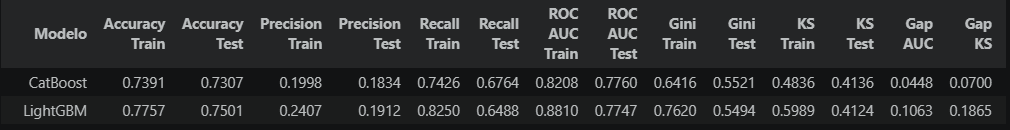

#### Construindo base de submissão (TARGET, SCORE)

In [113]:
y_prob_train = best_pipe_optuna.predict_proba(X_train)[:, 1]
y_prob_test  = best_pipe_optuna.predict_proba(X_test)[:, 1]
y_prob_kaggle = best_pipe_optuna.predict_proba(X_teste)[:, 1]

score_kaggle = np.round((1 - y_prob_kaggle) * 1000, 0).astype(int) #credit -> Bom pagador, acore alto. Mau Pagador, score baixo

submissao = pd.DataFrame({
    'SK_ID_CURR': ids_teste,
    'TARGET': y_prob_kaggle
})

submissao.to_csv('submissao_home_credit.csv', index=False)
submissao.head()

,SK_ID_CURR,TARGET
0,100001,0.0562
1,100005,0.1196
2,100042,0.0403
3,100065,0.0533
4,100066,0.0087


#### Visão de % da taxa de maus por ordenação do Decil (+ Taxa de maus nos primeirps Decis)

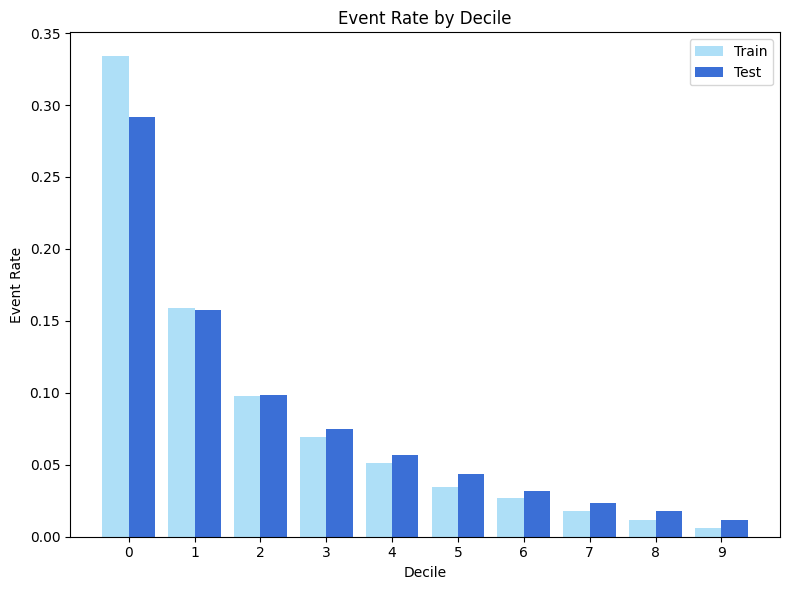

In [114]:
N_DECIS = 10

def calcular_decis(score, y_true, n_decis):
    df = pd.DataFrame({
        'score': score,
        'target': np.asarray(y_true)
    })

    df['decil'] = pd.qcut(df['score'], q=n_decis, labels=False, duplicates='drop')

    return (
        df.groupby('decil')['target']
        .mean()
        .reindex(range(n_decis))
    )


score_train = (1 - y_prob_train) * 1000
score_test  = (1 - y_prob_test) * 1000

event_rate_train = calcular_decis(score_train, y_train, N_DECIS)
event_rate_test  = calcular_decis(score_test, y_test, N_DECIS)

# Gráfico de barras agrupadas

x = np.arange(N_DECIS)
largura = 0.4

plt.figure(figsize=(8, 6))
plt.bar(x - largura/2, event_rate_train.values, width=largura, label='Train', color='#AEDFF7')
plt.bar(x + largura/2, event_rate_test.values,  width=largura, label='Test',  color='#3B6FD6')

plt.xlabel('Decile')
plt.ylabel('Event Rate')
plt.title('Event Rate by Decile')
plt.xticks(x, [str(i) for i in range(N_DECIS)])
plt.legend()
plt.tight_layout()
plt.show()

In [115]:
print(event_rate_train)
print(event_rate_test)

decil
0   0.3338
1   0.1587
2   0.0976
3   0.0693
4   0.0513
5   0.0342
6   0.0267
7   0.0177
8   0.0119
9   0.0060
Name: target, dtype: float64
decil
0   0.2915
1   0.1577
2   0.0982
3   0.0751
4   0.0569
5   0.0435
6   0.0319
7   0.0232
8   0.0180
9   0.0114
Name: target, dtype: float64


##### Visão de taxa de maus e taxa de maus acumulada por Decil

In [116]:
def calcular_tabela_decis(y_prob, y_true, n_decis):

    df = pd.DataFrame({
        'prob': y_prob,
        'target': np.asarray(y_true)
    })

    # qcut em -prob: decil 0 fica com as probabilidades mais altas (maior risco)
    df['decil'] = pd.qcut(-df['prob'], q=n_decis, labels=False, duplicates='drop')
    df['score'] = np.round((1 - df['prob']) * 1000, 0).astype(int)

    tabela = (
        df.groupby('decil')
        .agg(
            qtd_clientes    = ('target', 'count'),
            qtd_maus        = ('target', 'sum'),
            max_score       = ('score', 'max'),
        )
        .reindex(range(n_decis)) 
        .reset_index()
    )

    #tabela['taxa_maus'] = (tabela['qtd_maus'] / tabela['qtd_clientes'] * 100).round(2)
    #tabela['taxa_maus_acumulada'] = (tabela['qtd_maus'].cumsum() / tabela['qtd_maus'].sum() * 100).round(2)

    return tabela


# Comparação do treino e  Teste

tabela_treino = calcular_tabela_decis(y_prob_treino_optuna, y_train, n_decis=N_DECIS)
tabela_treino['split'] = 'Treino'

tabela_teste = calcular_tabela_decis(y_prob_teste_optuna, y_test, n_decis=N_DECIS)
tabela_teste['split'] = 'Teste'

df_decis_completo = pd.concat([tabela_treino, tabela_teste], ignore_index=True)
df_decis_completo = df_decis_completo[['split', 'decil', 'qtd_clientes', 'qtd_maus']]

display(tabela_treino)
display(tabela_teste)

,decil,qtd_clientes,qtd_maus,max_score,split
0,0,21526,7186,815,Treino
1,1,21526,3416,882,Treino
2,2,21525,2101,915,Treino
3,3,21526,1492,936,Treino
4,4,21526,1104,950,Treino
5,5,21525,737,961,Treino
6,6,21526,575,970,Treino
7,7,21525,381,977,Treino
8,8,21526,256,984,Treino
9,9,21526,129,997,Treino


,decil,qtd_clientes,qtd_maus,max_score,split
0,0,9226,2689,815,Teste
1,1,9225,1455,882,Teste
2,2,9225,906,916,Teste
3,3,9226,693,936,Teste
4,4,9225,525,950,Teste
5,5,9225,401,961,Teste
6,6,9226,294,970,Teste
7,7,9225,214,977,Teste
8,8,9225,166,984,Teste
9,9,9226,105,997,Teste
